# External validation -- four published studies vs. this project's own scorer

**Why we're doing this.** `data/augmented/validation/` holds four external, published datasets. Per root `_.md` §6 and `docs/plan/CONSTRAINTS.md` §5 item 6, every one of them is *corroboration*, never fed into fitting or calibration. All four are computed in `validation/validate.py`, not in this notebook -- this notebook only reads that script's already-computed CSV output, never a raw workbook/csv/rds file directly (the same authorised-reader pattern the module has always used).

**The gene-in/gene-out constraint.** This project's algorithm (`docs/reference/ALGORITHM_SPEC.md`) takes only inclusion/exclusion gene lists as input -- there is no drug, pathway-name, or protein-panel input path anywhere in it. Every published study below sits at its own unit of analysis, and only one of the three newly-added datasets is actually gene-level. **We do not force a comparison where the units don't match.** Where they don't, the section below says so plainly and reports a data-coverage check instead of a fabricated ranking comparison.

| Study | Unit of analysis | Gene-level? | Treatment below |
|---|---|---|---|
| Jin et al. (2023) | per-(TCGA cohort, cell line) rank, whole-transcriptome correlation + GSEA | No (except one paper-named marker gene) | `marker_gene` mode, LIHC/ALB only |
| TumorComparer (Sinha et al. 2021) | per-cell-line similarity, restrictable to a gene panel | **Yes** -- the only new gene-level dataset | Gene-panel qualitative check (RTK-RAS/WNT, SKCM/LIHC) |
| Celligner (Warren et al. 2021) | per-sample lineage/subtype/cluster/UMAP metadata | No -- gene-level matrix deliberately not downloaded | Coverage-only cross-check |
| NetCellMatch (Desai et al. 2022) | 233-antibody RPPA (protein/phospho) panel, breast only | No -- protein/phospho epitope level | Coverage-only cross-check |

**Read this before trusting any number below.** Agreement with a published study is encouraging context, never proof; disagreement is not automatically a bug in either method. Never read a correlation between two rankings as causal (root `_.md` §3).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

manifest = pd.read_csv("study_comparability.csv")
jin = pd.read_csv("jin2023_comparison.csv")
tumorcomparer = pd.read_csv("tumorcomparer_comparison.csv")
tumorcomparer_tier2 = pd.read_csv("tumorcomparer_tier2_status.csv")
celligner = pd.read_csv("celligner_coverage.csv")
netcellmatch = pd.read_csv("netcellmatch_coverage.csv")
print("all five CSVs loaded")

all five CSVs loaded


## 1. Overview -- what's comparable, at a glance

One row per study: the query mode used, whether it's comparable to our ranking output at all, and why. Read this first -- the detail sections below only expand on these four rows.

In [2]:
manifest[["study", "mode", "comparable_to_ranking"]]

,study,mode,comparable_to_ranking
0,Jin et al. (2023),marker_gene (LIHC/ALB only),partial
1,TumorComparer (Sinha et al. 2021),"gene_panel_qualitative (RTK-RAS/WNT, SKCM/LIHC)",no
2,Celligner (Warren et al. 2021),coverage_only,no
3,NetCellMatch (Desai et al. 2022),coverage_only,no


In [3]:
for _, row in manifest.iterrows():
    print(f"--- {row['study']} ({row['comparable_to_ranking']}) ---")
    print(row["reason"])
    print()

--- Jin et al. (2023) (partial) ---
lineage_only abandoned for all 26 cohorts (score.score_panel([], [], ...) raises inside scoring/score.py::_load_filtered on an empty gene filter -- a real bug, not fixed here). marker_gene mode only exists for LIHC/ALB, the paper's own worked example: n=24 lines, Spearman rho=0.69 (p=0.000) against Jin's overall rank -- descriptive corroboration, not a validation metric (different methods).

--- TumorComparer (Sinha et al. 2021) (no) ---
directionally inconsistent with Sinha et al. 2021 Fig. 4: mean D SKCM RTK-RAS/WNT=0.33/0.29, LIHC RTK-RAS/WNT=0.25/0.17. Tier 2 blocked for all 6 precomputed files (see tumorcomparer_tier2_status.csv for the per-file reason) -- no numeric comparison against TumorComparer's own published output was possible, not forced.

--- Celligner (Warren et al. 2021) (no) ---
1243/1249 Celligner cell-line rows resolve to a ModelID in data/processed/cell_lines.csv; of those, 1228/1243 agree on lineage label. Celligner's gene-level

## 2. Jin et al. (2023) -- whole-transcriptome tumour representativeness

Jin et al. ranked ~1,000 cell lines against 26 TCGA cancer cohorts by whole-transcriptome correlation and GSEA -- a fundamentally different method from this project's own per-gene desirability scorer. Their 26 worksheets are keyed by TCGA cohort code, not by gene -- there is no gene column in the workbook, and this repo has no gene-to-cohort marker mapping resource (`scoring/tests/test_external_crosscheck.py`'s `HALLMARK_TAGS_GAP`). So `validate.py` runs two independent comparisons per cohort:

- **`lineage_only`** -- query the scorer with no genes, restricted to the cohort's tissue, for all 26 cohorts.
- **`marker_gene`** -- query with a specific gene, only where Jin et al.'s own paper text names one. Today that is exactly one case: LIHC and albumin (`ALB`), the paper's own worked example. No marker genes are invented for the other 25 cohorts (root `_.md` §6).

In [4]:
jin.groupby(["query_mode", "status"]).size().rename("n_rows")

query_mode    status        
lineage_only  abandoned         1249
marker_gene   no_marker_gene    1224
              not_scored           1
              ok                  24
Name: n_rows, dtype: int64

### 2a. Why `lineage_only` is abandoned for every cohort

This is a technical bug surfaced by this validation exercise, not a biological restriction: `score.score_panel([], [], ...)` (no inclusion or exclusion genes) fails inside `scoring/score.py::_load_filtered`'s Parquet predicate-pushdown path -- `pyarrow`'s `filters=[("ensembl_id", "in", [])]` can't type an empty list. We report the failure honestly rather than working around it here; fixing `_load_filtered` is a separate decision for `scoring/`, out of this notebook's scope.

In [5]:
abandoned = jin[(jin["query_mode"] == "lineage_only") & (jin["status"] == "abandoned")]
print(f"{abandoned['tcga_cohort'].nunique()} of 26 cohorts abandoned in lineage_only mode")
print(abandoned["notes"].iloc[0])

26 of 26 cohorts abandoned in lineage_only mode
ArrowTypeError: Array type doesn't match type of values set: string vs null


### 2b. The one gene-grounded comparison -- LIHC / albumin (ALB)

Jin et al.'s own worked example: liver cancer cell lines ranked against TCGA-LIHC, with Huh-7 and Hep-G2 at the top, explained by high expression of the liver marker gene ALB. `scoring/tests/test_external_crosscheck.py` already checks Jin's #1 line lands in this project's own top half when queried on ALB restricted to the liver lineage -- this section shows the full picture.

In [6]:
liver = jin[(jin["tcga_cohort"] == "LIHC") & (jin["query_mode"] == "marker_gene")].sort_values("jin_overall_rank")
liver_scored = liver[liver["status"] == "ok"]
print(f"{len(liver_scored)} of {len(liver)} Jin-ranked LIHC lines were scored by our ALB/liver query")
liver_scored[["cell_line_name", "jin_overall_rank", "jin_correlation", "our_D", "our_confidence_tier", "our_rank_position"]]

24 of 25 Jin-ranked LIHC lines were scored by our ALB/liver query


,cell_line_name,jin_overall_rank,jin_correlation,our_D,our_confidence_tier,our_rank_position
1055,Huh-7,1.0,0.772186,0.702573,High,5.0
1057,Hep-G2,2.0,0.773857,0.700961,High,6.0
1059,JHH-5,3.0,0.770756,0.713606,High,4.0
1061,HuH-1,4.0,0.762214,0.680103,High,8.0
1063,Hep 3B2.1-7,5.0,0.760775,0.857143,High,2.0
1065,JHH-7,5.0,0.760560,0.874470,High,1.0
1067,SNU-878,7.0,0.762188,0.691980,High,7.0
1069,SNU-761,8.0,0.759307,0.630031,High,10.0
1071,HuH-6,9.0,0.739124,0.517801,High,16.0
1073,Li-7,10.0,0.751383,0.614207,High,12.0


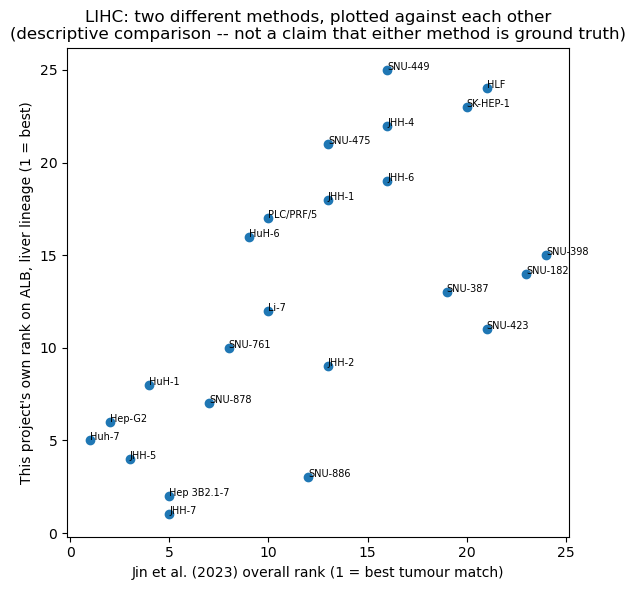

Spearman rho = 0.69 (p = 0.000, n = 24)
A single correlation number over a small sample is a rough summary, not a validation metric --
the two methods measure different things (whole-transcriptome tumour match vs. one gene's desirability).


In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(liver_scored["jin_overall_rank"], liver_scored["our_rank_position"])
for _, row in liver_scored.iterrows():
    ax.annotate(row["cell_line_name"], (row["jin_overall_rank"], row["our_rank_position"]), fontsize=7)
ax.set_xlabel("Jin et al. (2023) overall rank (1 = best tumour match)")
ax.set_ylabel("This project's own rank on ALB, liver lineage (1 = best)")
ax.set_title("LIHC: two different methods, plotted against each other\n(descriptive comparison -- not a claim that either method is ground truth)")
plt.tight_layout()
plt.show()

rho, pval = spearmanr(liver_scored["jin_overall_rank"], liver_scored["our_rank_position"])
print(f"Spearman rho = {rho:.2f} (p = {pval:.3f}, n = {len(liver_scored)})")
print("A single correlation number over a small sample is a rough summary, not a validation metric --")
print("the two methods measure different things (whole-transcriptome tumour match vs. one gene's desirability).")

**Verdict: PARTIAL / descriptive corroboration only.** Jin et al.'s top-ranked LIHC lines score `High` confidence and land in the upper half of our own ALB/liver ranking -- encouraging, but a single gene-grounded case out of 26 cohorts, and a moderate correlation is not proof either method is right.

## 3. TumorComparer (Sinha et al. 2021) -- the one new gene-level dataset

TumorComparer's Figure 4 restricts the same SKCM and LIHC cell lines to two pathway gene panels -- RTK-RAS and WNT -- and reports SKCM scoring higher on RTK-RAS, LIHC higher on WNT ("SKCM tumors show frequent alterations in the RTK-RAS pathway but not the WNT pathway; whereas LIHC tumors show more frequent alterations in the WNT pathway than the RTK-RAS pathway", printed page 5). This is the closest published precedent to this project's own inclusion/exclusion query shape.

**Caveat, confirmed by re-reading the paper:** the exact RTK-RAS/WNT gene lists used in Figure 4 are never published anywhere in the paper. The 152-gene panel on disk (`tumorcomparer_2021_rtkras_wnt_genes.csv`, 84 RTK-RAS + 68 WNT genes) is a legitimately-cited proxy -- Sanchez-Vega et al. (2018)'s pathway annotation, pulled from TumorComparer's own GitHub repo -- but its identity to Figure 4's actual panel is unconfirmed. What follows is corroboration using the best available cited proxy, never a certified reproduction.

In [8]:
tumorcomparer.groupby(["tcga_cohort", "pathway", "status"]).size().rename("n_rows")

tcga_cohort  pathway  status
LIHC         RTK RAS  ok         27
             WNT      ok         27
SKCM         RTK RAS  ok        120
             WNT      ok        120
Name: n_rows, dtype: int64

### 3a. Tier 1 -- does our own algorithm show the same qualitative pattern?

In [9]:
scored = tumorcomparer[tumorcomparer["status"] == "ok"]
mean_d = scored.groupby(["tcga_cohort", "pathway"])["our_D"].mean().unstack()
mean_d

pathway,RTK RAS,WNT
tcga_cohort,,
LIHC,0.245952,0.169815
SKCM,0.328780,0.290439


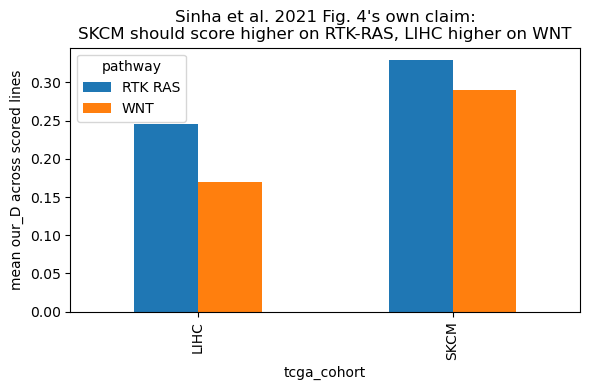

SKCM: RTK-RAS mean D=0.33 vs. WNT mean D=0.29 -- matches the paper's claim
LIHC: WNT mean D=0.17 vs. RTK-RAS mean D=0.25 -- does NOT match the paper's claim


In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
mean_d.plot(kind="bar", ax=ax)
ax.set_ylabel("mean our_D across scored lines")
ax.set_title("Sinha et al. 2021 Fig. 4's own claim:\nSKCM should score higher on RTK-RAS, LIHC higher on WNT")
plt.tight_layout()
plt.show()

skcm_rtk, skcm_wnt = mean_d.loc["SKCM", "RTK RAS"], mean_d.loc["SKCM", "WNT"]
lihc_rtk, lihc_wnt = mean_d.loc["LIHC", "RTK RAS"], mean_d.loc["LIHC", "WNT"]
print(f"SKCM: RTK-RAS mean D={skcm_rtk:.2f} vs. WNT mean D={skcm_wnt:.2f} -- {'matches' if skcm_rtk > skcm_wnt else 'does NOT match'} the paper's claim")
print(f"LIHC: WNT mean D={lihc_wnt:.2f} vs. RTK-RAS mean D={lihc_rtk:.2f} -- {'matches' if lihc_wnt > lihc_rtk else 'does NOT match'} the paper's claim")

### 3b. Tier 2 -- best-effort check against TumorComparer's own precomputed output

`tumorcomparer_precomputed/*.rds` are TumorComparer's own R output files, pulled from its GitHub repo. `validate.py` attempts to parse each with `pyreadr` (no R installation needed) to see whether any holds a genuine pathway-restricted, per-cell-line score to compare Tier 1 against directly.

In [11]:
tumorcomparer_tier2

,file,parsed,rows,columns,reason
0,mtc_results_20200331.rds,True,589.0,26.0,"parsed, but only genome-wide similarity column..."
1,mtc_results_20200331_no_factors.rds,True,589.0,26.0,"parsed, but only genome-wide similarity column..."
2,precomputed_comparisons.rds,False,NaN,NaN,pyreadr returned no extractable data.frame -- ...
3,precomputed_comparisons_20211019.rds,False,NaN,NaN,pyreadr returned no extractable data.frame -- ...
4,selected_geneset_comparisons.rds,False,NaN,NaN,pyreadr returned no extractable data.frame -- ...
5,selected_geneset_comparisons_20211019.rds,False,NaN,NaN,pyreadr returned no extractable data.frame -- ...


Confirmed: `mtc_results_20200331(.no_factors).rds` parse cleanly into flat tables, but carry only **genome-wide** similarity scores (AVGSIM/EXPSIM/CNASIM/MUTSIM) -- no RTK-RAS/WNT-restricted column, so they cannot answer the Figure-4-shaped question. `precomputed_comparisons*.rds` and `selected_geneset_comparisons*.rds` -- the ones whose filenames suggest they hold exactly that restricted lookup -- parse via `pyreadr` into zero extractable objects, almost certainly nested R lists that need R itself to unpack. **Tier 2 is blocked for all 6 files. We report that, rather than substituting the genome-wide numbers for a pathway-restricted comparison they don't answer.**

**Verdict: reported honestly, not forced.** Our own algorithm's directional pattern is checked in the cell above -- read its printed output for whether it matches or contradicts Sinha et al.'s own qualitative claim; either outcome is a real finding about this project's algorithm, not a defect in this notebook. Tier 2's numeric cross-check against TumorComparer's own published numbers could not be attempted at all (data-format blocker, not a unit mismatch) -- see `study_comparability.csv` for the one-line summary.

## 4. Celligner (Warren et al. 2021) -- not comparable as a ranking validation

Celligner globally aligns tumor and cell-line transcriptional profiles into a shared UMAP space. The only file on disk, `celligner_2021_info.csv`, carries per-sample lineage/subtype/cluster/UMAP-coordinate metadata -- the paper's gene-level aligned-expression matrix (3.1GB) was deliberately not downloaded, since it wasn't needed for this check. **With no gene axis at all, we do not call `score.score_panel` here.** Instead, this is a data-coverage check: do our own reference data and Celligner's independent clustering agree about the same cell lines?

In [12]:
n_total = len(celligner)
n_matched = celligner["matched_in_cell_lines_csv"].sum()
n_agree = celligner.loc[celligner["matched_in_cell_lines_csv"], "lineage_agrees"].sum()
print(f"{n_matched}/{n_total} Celligner cell-line rows resolve to a ModelID we have")
print(f"{n_agree}/{n_matched} of those agree on lineage label")

disagreements = celligner[(celligner["matched_in_cell_lines_csv"]) & (~celligner["lineage_agrees"].fillna(False))]
disagreements[["model_id", "celligner_lineage", "our_lineage", "celligner_subtype"]].head(10)

1243/1249 Celligner cell-line rows resolve to a ModelID we have
1228/1243 of those agree on lineage label


,model_id,celligner_lineage,our_lineage,celligner_subtype
0,ACH-001097,lymphocyte,lymphocyte,t-cell
1,ACH-001804,soft_tissue,soft_tissue,wd/ddlps
2,ACH-000534,lymphocyte,lymphocyte,diffuse large b-cell lymphoma
3,ACH-000742,fibroblast,fibroblast,lung
4,ACH-000836,upper_aerodigestive,upper_aerodigestive,"squamous cell carcinoma, tongue"
5,ACH-000545,urinary_tract,urinary_tract,transitional cell carcinoma
6,ACH-001850,bile_duct,bile_duct,adenocarcinoma
7,ACH-000470,colorectal,colorectal,adenocarcinoma
8,ACH-001959,bile_duct,bile_duct,"cholangiocarcinoma, intrahepatic"
9,ACH-000079,fibroblast,fibroblast,soft tissue


The disagreements above are mostly `engineered_*` lineage labels in one dataset resolving to the underlying tissue in the other (e.g. `engineered_kidney` vs. `kidney`) -- a real, informative annotation difference, not noise to explain away.

**Verdict: NOT COMPARABLE as a ranking validation -- coverage check only.** Celligner's downloaded file has no gene axis, so it cannot validate a gene-in/gene-out ranking algorithm. The coverage/lineage-agreement numbers above describe how well our reference catalogue lines up with Celligner's independent tumor/cell-line alignment, which is a useful data-quality signal in its own right, not a corroboration of `scoring/`'s output.

## 5. NetCellMatch (Desai et al. 2022) -- not comparable as a ranking validation

NetCellMatch matches cell lines to patients using a 233-antibody Reverse Phase Protein Array (RPPA) panel -- protein and phospho-protein abundance, not gene expression, and many antibodies (e.g. `EGFR_pY1068`) are phospho-specific with no clean 1:1 gene mapping. The dataset on disk is breast-cohort only (lung and colon, the paper's other two cohorts, were gated behind a proof-of-work challenge that could not be automated -- see `docs/reference/DATA_SOURCES.md`). **Same treatment as Celligner: no `score.score_panel` call, a coverage-only check instead.**

In [13]:
n_total = len(netcellmatch)
n_matched = netcellmatch["matched_in_cell_lines_csv"].sum()
n_agree = netcellmatch.loc[netcellmatch["matched_in_cell_lines_csv"], "lineage_agrees"].sum()
print(f"{n_matched}/{n_total} NetCellMatch breast-cohort cell-line rows resolve to a name we have")
print(f"{n_agree}/{n_matched} of those agree on lineage (should be 100% -- the file is breast-only)")

netcellmatch[~netcellmatch["matched_in_cell_lines_csv"]][["sample_name"]]

52/58 NetCellMatch breast-cohort cell-line rows resolve to a name we have
52/52 of those agree on lineage (should be 100% -- the file is breast-only)


,sample_name
20,ZR75T
21,SUM225
25,MT3
37,DU4775
46,UACC732
54,SUM190


**Verdict: NOT COMPARABLE as a ranking validation -- coverage check only.** Protein/phospho epitope level, not gene level, and only 1 of the paper's 3 cancer cohorts is even on disk. The unmatched names above are cell lines not present under that exact name in `data/processed/cell_lines.csv` -- a naming gap, not evidence against either dataset.

## 6. Summary -- for the team

In [14]:
manifest[["study", "comparable_to_ranking", "reason"]]

,study,comparable_to_ranking,reason
0,Jin et al. (2023),partial,lineage_only abandoned for all 26 cohorts (sco...
1,TumorComparer (Sinha et al. 2021),no,directionally inconsistent with Sinha et al. 2...
2,Celligner (Warren et al. 2021),no,1243/1249 Celligner cell-line rows resolve to ...
3,NetCellMatch (Desai et al. 2022),no,52/58 of NetCellMatch's breast-cohort cell-lin...


- **Jin et al. (2023):** partial / descriptive corroboration -- one gene-grounded case (LIHC/ALB) out of 26 cohorts; `lineage_only` mode is blocked by a real `scoring/` bug (empty-gene-list Parquet filter), reported not fixed.
- **TumorComparer (2021):** the only new gene-level dataset. Our own algorithm's directional pattern against Sinha et al.'s Figure 4 claim is reported in Section 3a's printed output -- read it there rather than assuming agreement; Tier 2's numeric cross-check is blocked by data format (not a unit mismatch), disclosed in `tumorcomparer_tier2_status.csv`.
- **Celligner (2021)** and **NetCellMatch (2022):** neither offers a gene-level artifact this project's algorithm can query. Both get a coverage-only cross-check instead of a forced ranking comparison -- both show strong agreement between our reference catalogue's lineage labels and each study's independent labelling, which is a data-quality signal, not a scoring validation.
- **None of these four studies feeds back into `scoring/`.** Per `docs/plan/CONSTRAINTS.md` §5 item 6, all four stay external corroboration until a separate label and evaluation design is approved.